# 3.4 ベイズモデル比較 (Bayesian Model Comparison)

本ノートブックでは、クロスバリデーション（交差検証）などのヒューリスティックに頼ることなく、確率の原理のみに基づいてモデルの複雑さを自動的に決定する**ベイズモデル比較 (Bayesian Model Comparison)** の枠組みを学びます。
モデルエビデンス（周辺尤度）の定式化、オッカムの剃刀（**PRML Figure 3.12**）の幾何学的解釈、および多項式次数やモデル構造の選択実験を実装・可視化します。

## 3.4.1 モデルエビデンスと事後モデル確率

比較したい $L$ 個のモデル集合 $\{\mathcal{M}_i\}_{i=1}^L$ を考えます。
学習データ $\mathcal{D}$ が与えられたときのモデル $\mathcal{M}_i$ の事後確率はベイズの定理によって表されます：
$$ p(\mathcal{M}_i | \mathcal{D}) \propto p(\mathcal{D} | \mathcal{M}_i) p(\mathcal{M}_i) $$
ここで $p(\mathcal{M}_i)$ はモデルの事前確率であり、事前情報がなければ一様分布 $p(\mathcal{M}_i) = 1/L$ とします。
したがって、モデル選択の鍵を握るのは**モデルエビデンス（周辺尤度）** $p(\mathcal{D} | \mathcal{M}_i)$ です：
$$ p(\mathcal{D} | \mathcal{M}_i) = \int p(\mathcal{D} | \mathbf{w}, \mathcal{M}_i) p(\mathbf{w} | \mathcal{M}_i) d\mathbf{w} $$

2つのモデルの相対的な比較は**ベイズ因子 (Bayes Factor)** によって測られます：
$$ \frac{p(\mathcal{D} | \mathcal{M}_i)}{p(\mathcal{D} | \mathcal{M}_j)} $$

### オッカムの剃刀 (Occam's Razor) の解析的理解
パラメータが1つの場合、事前分布が幅 $\Delta w_{\text{prior}}$ の一様分布で、事後分布が最頻値 $w_{\text{MAP}}$ 付近の幅 $\Delta w_{\text{post}}$ に局在していると仮定すると、積分は
$$ p(\mathcal{D}) = \int p(\mathcal{D}|w) p(w) dw \simeq p(\mathcal{D}|w_{\text{MAP}}) \frac{\Delta w_{\text{post}}}{\Delta w_{\text{prior}}} $$
対数をとると：
$$ \ln p(\mathcal{D}) \simeq \underbrace{\ln p(\mathcal{D}|w_{\text{MAP}})}_{\text{データ適合度}} + \underbrace{\ln \left( \frac{\Delta w_{\text{post}}}{\Delta w_{\text{prior}}} \right)}_{\text{オッカム因子 (ペナルティ)}} $$
$\Delta w_{\text{post}} < \Delta w_{\text{prior}}$ であるため、オッカム因子は常に負の値であり、不要に柔軟なモデルほど大きなペナルティを受けます。
$M$ 個の独立なパラメータがある場合、オッカム因子はおよそ $- \frac{M}{2} \ln \frac{\Delta w_{\text{prior}}}{\Delta w_{\text{post}}}$ となり、パラメータ数 $M$ に比例してペナルティが増加します。

Plot saved to: result/fig3_12_occams_razor.png


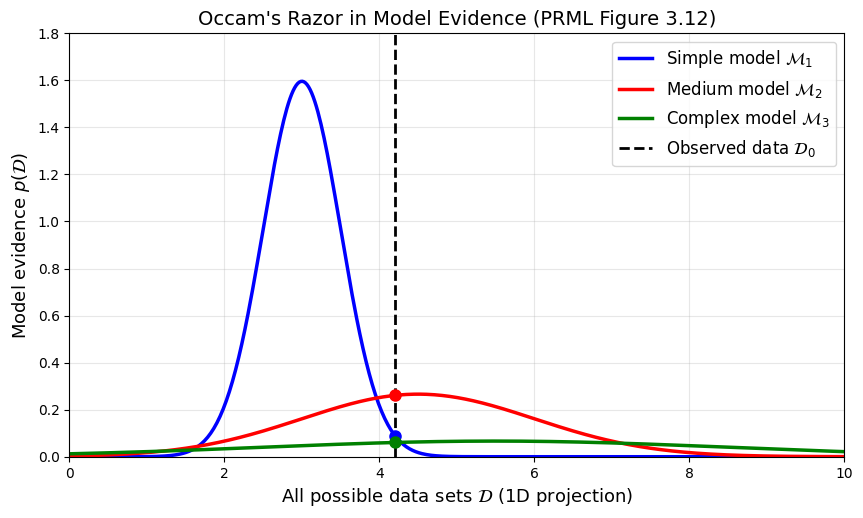

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# PRML Figure 3.12 の再現: 全データセット空間における確率分布 p(D)
d = np.linspace(0, 10, 500)

# 3つのモデル: M1 (単純), M2 (中程度), M3 (複雑)
# 確率密度の積分が 1 に規格化されている
p_m1 = 2.0 * np.exp(-0.5 * ((d - 3.0) / 0.5)**2) / (np.sqrt(2 * np.pi) * 0.5)
p_m2 = 1.0 * np.exp(-0.5 * ((d - 4.5) / 1.5)**2) / (np.sqrt(2 * np.pi) * 1.5)
p_m3 = 0.5 * np.exp(-0.5 * ((d - 5.5) / 3.0)**2) / (np.sqrt(2 * np.pi) * 3.0)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(d, p_m1, 'b-', lw=2.5, label=r'Simple model $\mathcal{M}_1$')
ax.plot(d, p_m2, 'r-', lw=2.5, label=r'Medium model $\mathcal{M}_2$')
ax.plot(d, p_m3, 'g-', lw=2.5, label=r'Complex model $\mathcal{M}_3$')

# 観測されたデータ D_0
d_0 = 4.2
ax.axvline(d_0, color='black', linestyle='--', lw=2, label=r'Observed data $\mathcal{D}_0$')

# 交点のマーク
idx_0 = np.argmin(np.abs(d - d_0))
ax.plot(d_0, p_m1[idx_0], 'bo', markersize=8)
ax.plot(d_0, p_m2[idx_0], 'ro', markersize=8)
ax.plot(d_0, p_m3[idx_0], 'go', markersize=8)

ax.set_xlabel('All possible data sets $\mathcal{D}$ (1D projection)', fontsize=13)
ax.set_ylabel(r'Model evidence $p(\mathcal{D})$', fontsize=13)
ax.set_title("Occam's Razor in Model Evidence (PRML Figure 3.12)", fontsize=14)
ax.set_xlim(0, 10)
ax.set_ylim(0, 1.8)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig3_12_occams_razor.png')
plt.show()

## 3.4.2 多項式回帰におけるモデルエビデンスの評価

PRML 第1章の多項式フィッティングの例を取り上げ、多項式の次数 $M \in \{0, 1, \dots, 8\}$ に対する対数エビデンス（対数周辺尤度）$\ln p(\mathbf{t} | M, \alpha, \beta)$ を計算します。
第3.5.1節の式 (3.86) より、ベイズ線形回帰の対数エビデンスは
$$ \ln p(\mathbf{t} | \alpha, \beta) = \frac{M}{2} \ln \alpha + \frac{N}{2} \ln \beta - E(\mathbf{m}_N) - \frac{1}{2} \ln |\mathbf{A}| - \frac{N}{2} \ln(2\pi) $$
ここで $\mathbf{A} = \alpha \mathbf{I} + \beta \mathbf{\Phi}^T \mathbf{\Phi}$ です。

Plot saved to: result/fig3_model_evidence_polynomial.png


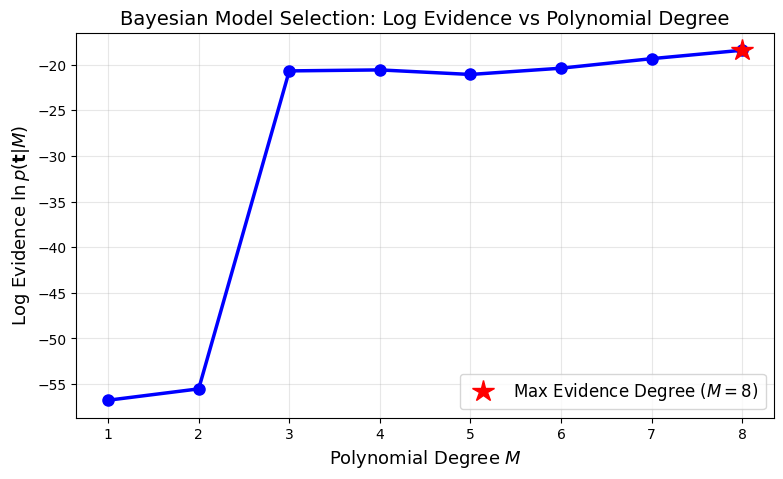

In [2]:
# 多項式次数 M に対するモデルエビデンスの計算
from common.regression_utils import PolynomialBasis, BayesianLinearRegression

np.random.seed(42)
N_pts = 15
x_train_poly = np.sort(np.random.uniform(0, 1, N_pts))
# 真の生成関数 sin(2*pi*x)
t_train_poly = np.sin(2 * np.pi * x_train_poly) + np.random.normal(0, 0.2, N_pts)

alpha = 5e-3 # 広い事前分布
beta = 1.0 / (0.2**2) # 既知のノイズ分散

degrees = list(range(1, 9))
log_evidences = []

for deg in degrees:
    poly = PolynomialBasis(degree=deg)
    Phi_tr = poly(x_train_poly)
    blr = BayesianLinearRegression(alpha=alpha, beta=beta).fit(Phi_tr, t_train_poly)
    log_ev = blr.log_marginal_likelihood()
    log_evidences.append(log_ev)

best_deg = degrees[np.argmax(log_evidences)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(degrees, log_evidences, 'bo-', lw=2.5, markersize=8)
ax.plot(best_deg, np.max(log_evidences), 'r*', markersize=16, label=f'Max Evidence Degree ($M = {best_deg}$)')

ax.set_xlabel('Polynomial Degree $M$', fontsize=13)
ax.set_ylabel(r'Log Evidence $\ln p(\mathbf{t}|M)$', fontsize=13)
ax.set_title('Bayesian Model Selection: Log Evidence vs Polynomial Degree', fontsize=14)
ax.set_xticks(degrees)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

save_plot(fig, 'result', 'fig3_model_evidence_polynomial.png')
plt.show()